In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.cluster.hierarchy import dendrogram, linkage

from src.features import FEATURE_COLUMNS
from src.clustering import elbow_and_silhouette, fit_kmeans, fit_hierarchical, label_personas

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

In [2]:
# df: raw-unit features, used for persona labeling and plots (real dollars/days,
# easy to interpret). X: log-transformed features the scaler was actually fit on
# in notebook 03 — clustering below runs on X_scaled, not raw units.
df = pd.read_csv("../data/processed/customer_features.csv")
X = pd.read_csv("../data/processed/customer_features_log.csv")
scaler = joblib.load("../models/scaler.joblib")

X_scaled = scaler.transform(X[FEATURE_COLUMNS])
print(f"Customers: {len(df):,}")

Customers: 4,327


In [3]:
metrics_df = elbow_and_silhouette(X_scaled, k_range=range(2, 11))
metrics_df

,k,inertia,silhouette
0,2,18685.246193,0.491361
1,3,11223.639831,0.489719
2,4,8473.087123,0.508872
3,5,6912.067328,0.508196
4,6,5834.242267,0.451918
5,7,4928.928513,0.470964
6,8,4106.471777,0.426291
7,9,3707.783919,0.415026
8,10,3387.781073,0.414901


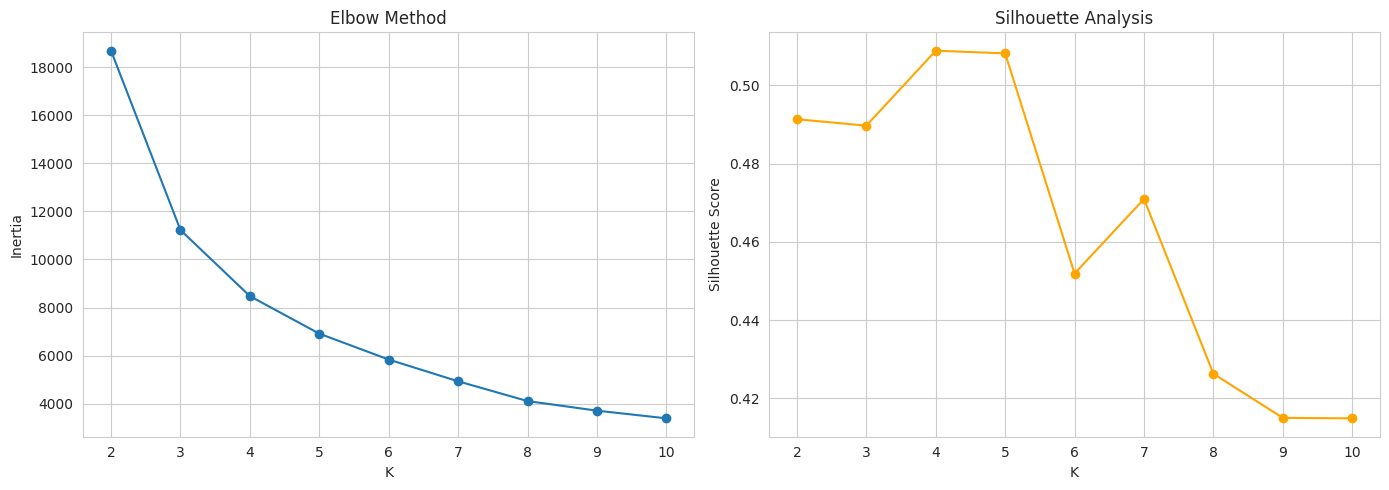

K with highest silhouette score: 4


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(metrics_df["k"], metrics_df["inertia"], marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(metrics_df["k"], metrics_df["silhouette"], marker="o", color="orange")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.savefig("../reports/figures/04_elbow_silhouette.png", dpi=120)
plt.show()

best_k = int(metrics_df.loc[metrics_df["silhouette"].idxmax(), "k"])
print(f"K with highest silhouette score: {best_k}")

In [5]:
chosen_k = best_k  # override manually here if the elbow plot suggests otherwise, e.g. chosen_k = 5

kmeans_model, kmeans_labels = fit_kmeans(X_scaled, n_clusters=chosen_k)
df["Cluster"] = kmeans_labels
df["Cluster"].value_counts().sort_index()

Cluster
0     989
1    2224
2     990
3     124
Name: count, dtype: int64

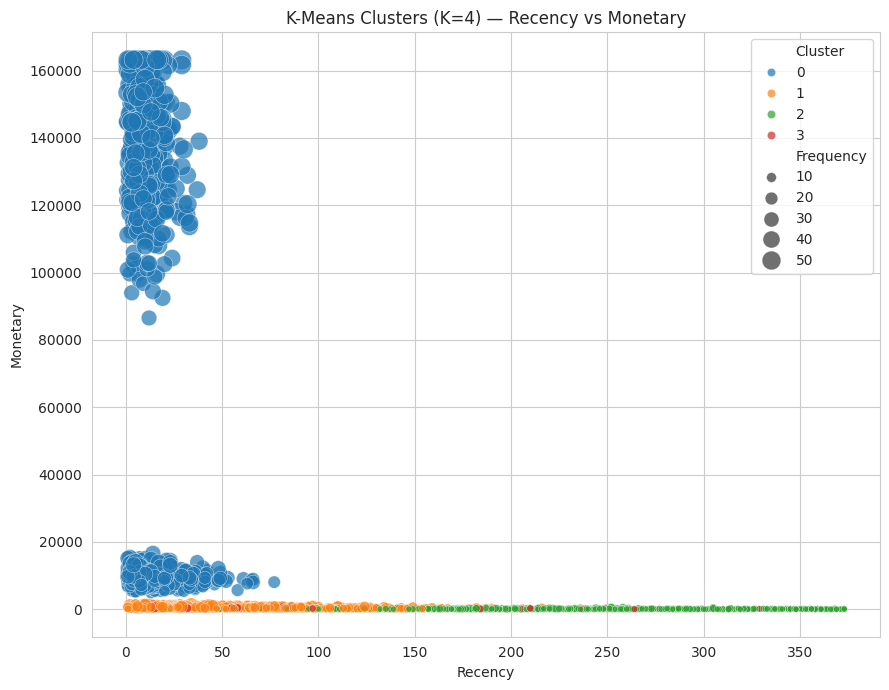

In [6]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df, x="Recency", y="Monetary",
    hue="Cluster", size="Frequency", sizes=(20, 200),
    palette="tab10", alpha=0.7
)
plt.title(f"K-Means Clusters (K={chosen_k}) — Recency vs Monetary")
plt.tight_layout()
plt.savefig("../reports/figures/04_kmeans_clusters.png", dpi=120)
plt.show()

In [7]:
personas = label_personas(df, cluster_col="Cluster")
for cid, name in sorted(personas.items()):
    print(f"Cluster {cid}: {name}")

df["Persona"] = df["Cluster"].map(personas)
df.groupby("Persona")[["Recency", "Frequency", "Monetary", "AvgBasketValue"]].mean().round(1)

Cluster 0: Champions (Recent, Frequent, High-Spend)
Cluster 1: Regular Customers
Cluster 2: At-Risk / Churned Customers
Cluster 3: High Cancellation Rate (Risk Watch)


,Recency,Frequency,Monetary,AvgBasketValue
Persona,,,,
At-Risk / Churned Customers,181.7,1.5,84.5,55.8
"Champions (Recent, Frequent, High-Spend)",13.7,34.1,60684.3,1391.6
High Cancellation Rate (Risk Watch),85.0,4.3,242.4,57.4
Regular Customers,41.6,7.8,439.6,56.4


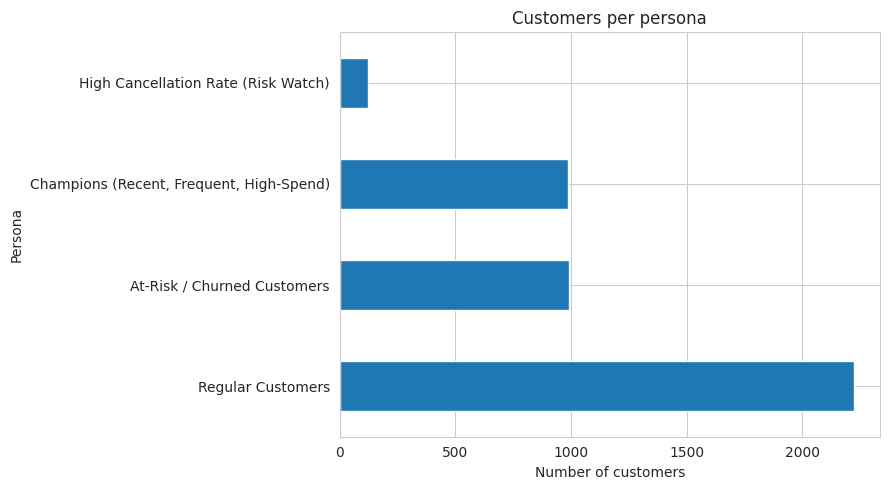

In [8]:
df["Persona"].value_counts().plot(kind="barh")
plt.xlabel("Number of customers")
plt.title("Customers per persona")
plt.tight_layout()
plt.savefig("../reports/figures/04_persona_sizes.png", dpi=120)
plt.show()

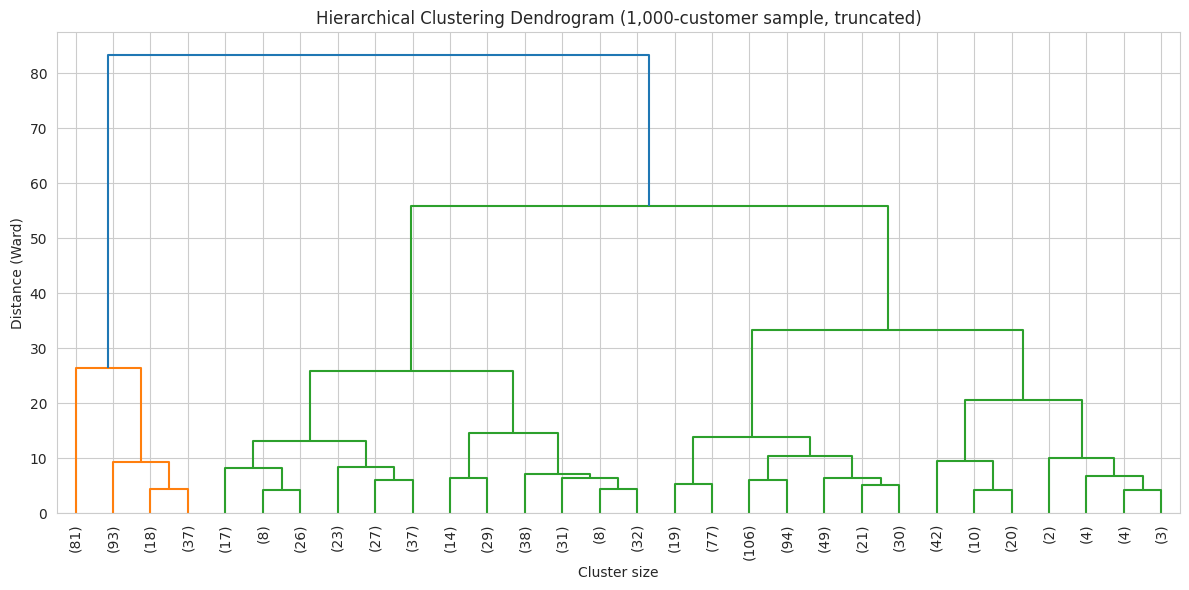

In [9]:
sample_size = min(1000, len(X_scaled))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_scaled), size=sample_size, replace=False)

linked = linkage(X_scaled[sample_idx], method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title(f"Hierarchical Clustering Dendrogram ({sample_size:,}-customer sample, truncated)")
plt.xlabel("Cluster size")
plt.ylabel("Distance (Ward)")
plt.tight_layout()
plt.savefig("../reports/figures/04_dendrogram.png", dpi=120)
plt.show()

In [10]:
hc_model, hc_labels = fit_hierarchical(X_scaled[sample_idx], n_clusters=chosen_k)

# Compare against K-Means labels on the same sample
kmeans_sample_labels = df["Cluster"].values[sample_idx]
pd.crosstab(pd.Series(kmeans_sample_labels, name="KMeans"), pd.Series(hc_labels, name="Hierarchical"))

Hierarchical,0,1,2,3
KMeans,,,,
0,229,0,0,0
1,0,55,70,396
2,0,0,220,0
3,0,30,0,0


In [11]:
df.to_csv("../data/processed/customer_features_clustered.csv", index=False)
joblib.dump(kmeans_model, "../models/kmeans_model.joblib")
joblib.dump(personas, "../models/persona_labels.joblib")
print("Saved kmeans_model.joblib and persona_labels.joblib")

Saved kmeans_model.joblib and persona_labels.joblib
